In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

https://www.kaggle.com/datasets/vivek468/superstore-dataset-final

In [3]:
data = pd.read_csv('/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv',encoding='latin1')
df = pd.DataFrame(data)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### EDA And Feature Engineering

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
df.shape

(9994, 21)

In [6]:
df['Country'].value_counts()

Country
United States    9994
Name: count, dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.drop_duplicates()

In [9]:
df['Ship Mode'].value_counts()

Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

In [10]:
df['Segment'].value_counts()

Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

In [11]:
df['Category'].value_counts()

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

Text(0.5, 1.0, 'Mean Profit by Category')

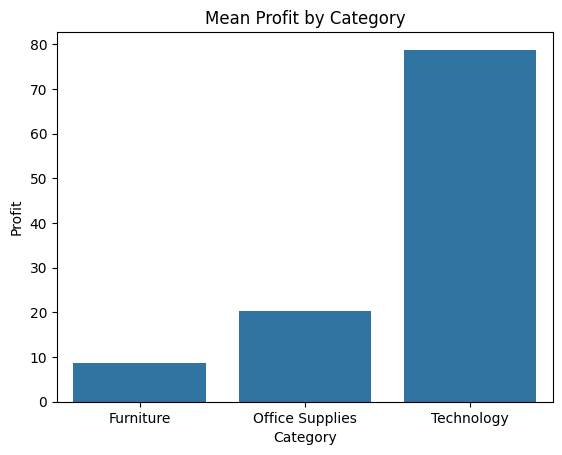

In [12]:
# # Category Plot
sns.barplot(x='Category', y='Profit', data=df, estimator='mean', errorbar=None)
plt.title('Mean Profit by Category')

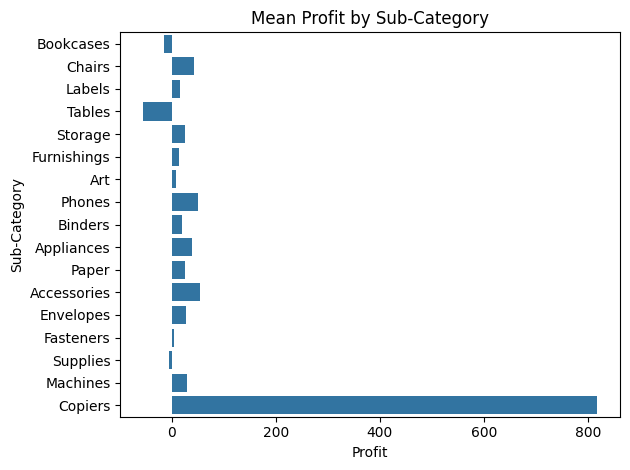

In [13]:
# Statistical check: How much does the average Profit vary?
sns.barplot(x='Profit', y='Sub-Category', data=df, estimator='mean', errorbar=None)
plt.title('Mean Profit by Sub-Category')


plt.tight_layout()

In [14]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

<Axes: xlabel='Quantity'>

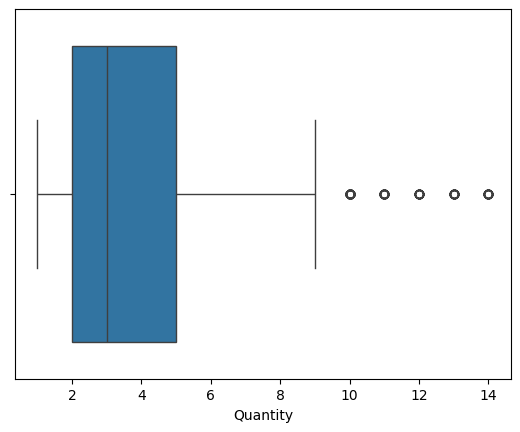

In [15]:
sns.boxplot(data=df,x='Quantity')

<Axes: >

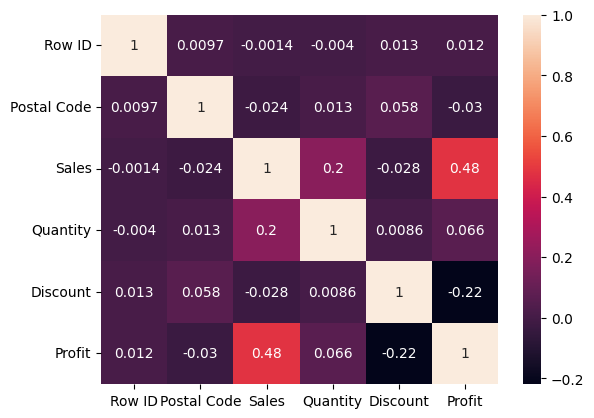

In [16]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [17]:
# 1. Calculate Base Price (Original price before discount)
# We use a small epsilon or fillna to avoid division by zero if Discount is 1.0
df['Base_Price'] = df['Sales'] / (1 - df['Discount'])

# 2. Calculate Unit Price
df['Unit_Price'] = df['Sales'] / df['Quantity']

# 3. Calculate the actual Dollar Amount saved
df['Discount_Amount'] = df['Base_Price'] - df['Sales']

print(df[['Sales', 'Quantity', 'Discount', 'Base_Price', 'Unit_Price']].head())

      Sales  Quantity  Discount  Base_Price  Unit_Price
0  261.9600         2      0.00      261.96    130.9800
1  731.9400         3      0.00      731.94    243.9800
2   14.6200         2      0.00       14.62      7.3100
3  957.5775         5      0.45     1741.05    191.5155
4   22.3680         2      0.20       27.96     11.1840


In [18]:
# Convert to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Create a clean, short integer column
df['Lead_Time'] = (df['Ship Date'] - df['Order Date']).dt.days

# Check the data type - it should be 'int64' now
print(df[['Order Date', 'Ship Date', 'Lead_Time']].head())

  Order Date  Ship Date  Lead_Time
0 2016-11-08 2016-11-11          3
1 2016-11-08 2016-11-11          3
2 2016-06-12 2016-06-16          4
3 2015-10-11 2015-10-18          7
4 2015-10-11 2015-10-18          7


In [19]:
# Extract Month (1-12) - Great for seeing seasonal trends like Christmas
df['Order_Month'] = df['Order Date'].dt.month

# Extract Day of Week (0=Monday, 6=Sunday) - Helps see weekend vs weekday spikes
df['Order_DayOfWeek'] = df['Order Date'].dt.dayofweek

# Extract Year - Helps the model understand long-term growth
df['Order_Year'] = df['Order Date'].dt.year

In [20]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Base_Price',
       'Unit_Price', 'Discount_Amount', 'Lead_Time', 'Order_Month',
       'Order_DayOfWeek', 'Order_Year'],
      dtype='object')

In [21]:
# Removing irrelevant columns 
remove_cols = ['Row ID','Order ID','Order Date','Ship Date','Customer ID','Customer Name','Product ID','Product Name','Postal Code','Country','City']
df = df.drop(columns = remove_cols,axis=1)
df.shape

(9994, 17)

## Model Selection & Hyperparameter Tuning

#### Encoding Categorical Data

In [22]:
from sklearn.model_selection import KFold

In [23]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ML

In [24]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR 
from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score


In [25]:
cols_to_encode = ['Category','Ship Mode','Segment','Region','Sub-Category','State']

df = pd.get_dummies(df,columns=cols_to_encode,drop_first=True)

df = df.astype({col: int for col in df.select_dtypes('bool').columns})


In [26]:
df.shape

(9994, 85)

#### Defining Input and Output variables then scaling them

In [27]:
X = df.drop(columns=['Profit'])
y= df['Profit']

In [28]:
df.head()

,Sales,Quantity,Discount,Profit,Base_Price,Unit_Price,Discount_Amount,Lead_Time,Order_Month,Order_DayOfWeek,...,State_South Dakota,State_Tennessee,State_Texas,State_Utah,State_Vermont,State_Virginia,State_Washington,State_West Virginia,State_Wisconsin,State_Wyoming
0,261.9600,2,0.00,41.9136,261.96,130.9800,0.0000,3,11,1,...,0,0,0,0,0,0,0,0,0,0
1,731.9400,3,0.00,219.5820,731.94,243.9800,0.0000,3,11,1,...,0,0,0,0,0,0,0,0,0,0
2,14.6200,2,0.00,6.8714,14.62,7.3100,0.0000,4,6,6,...,0,0,0,0,0,0,0,0,0,0
3,957.5775,5,0.45,-383.0310,1741.05,191.5155,783.4725,7,10,6,...,0,0,0,0,0,0,0,0,0,0
4,22.3680,2,0.20,2.5164,27.96,11.1840,5.5920,7,10,6,...,0,0,0,0,0,0,0,0,0,0


In [29]:
# 1. Split first
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Initialize scaler
scaler = StandardScaler()

# 3. Scaling only those who doesn't have boolean values
cols_to_scale = ['Base_Price', 'Unit_Price','Discount_Amount','Sales','Quantity']
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# 4. Transform ONLY (no fitting!) the Test data
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print(X_train[cols_to_scale].head())

      Base_Price  Unit_Price  Discount_Amount     Sales  Quantity
4100   -0.368951   -0.420834        -0.159784 -0.384372 -1.248106
2586   -0.041090   -0.181511        -0.192965  0.039460  1.454659
9194   -0.301693   -0.387778        -0.149005 -0.305685  1.454659
2002   -0.252013   -0.206922        -0.192965 -0.223178 -0.347184
7225   -0.342031   -0.381703        -0.192965 -0.335268  0.103276


In [30]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "SVR": SVR(),                 
    "Random Forest": RandomForestRegressor(n_jobs=-1),        # Uses all CPU cores
    "Gradient Boosting": GradientBoostingRegressor(),         # Cannot use n_jobs natively
}

In [31]:
# These variables hold the values to prevent rendering bugs
trees_count_list = [50, 100]
leaf_samples_list = [1, 2, 4]
boosting_depth_list = [3, 5]
iterations_list = [5000, 10000]

param_grids = {
    "Linear Regression": {
        "fit_intercept": [True, False]
    },
    "Ridge": {
        "alpha": [0.01, 0.1, 1, 10],
        "solver": ["auto", "svd", "cholesky", "lsqr"]
    },
    "Lasso": {
        "alpha": [0.01, 0.1, 1],
        "max_iter": iterations_list
    },
    "ElasticNet": {
        "alpha": [0.01, 0.1, 1],
        "l1_ratio": [0.2, 0.5, 0.8],
        "max_iter": iterations_list
    },
    "SVR": {
        "C": [0.1, 1, 10],
        "epsilon": [0.01, 0.1, 0.2],
        "kernel": ["rbf", "linear"]
    },
    "Random Forest": {
        "n_estimators": trees_count_list,
        "max_depth": [None, 10, 20],
        "min_samples_leaf": leaf_samples_list
    },
    "Gradient Boosting": {
        "n_estimators": trees_count_list,
        "learning_rate": [0.05, 0.1],
        "max_depth": boosting_depth_list,
        "subsample": [0.8, 1.0]
    }
}


In [32]:
results = {}
best_models = {}

for name, model in models.items():

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=kf,
        scoring='r2', # r2 is for regression and 'accuracy' is for classification
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    # Store results
    results[name] = {
        "Best Params": grid.best_params_,
        "Best CV Score": grid.best_score_
    }

    # Store best trained model
    best_models[name] = grid.best_estimator_ 

    print(f"\n{name}")
    print("Best Params:", grid.best_params_)
    print("Best CV Score:", round(grid.best_score_, 4))


Linear Regression
Best Params: {'fit_intercept': True}
Best CV Score: 0.7893

Ridge
Best Params: {'alpha': 10, 'solver': 'lsqr'}
Best CV Score: 0.7898

Lasso
Best Params: {'alpha': 0.1, 'max_iter': 5000}
Best CV Score: 0.7911

ElasticNet
Best Params: {'alpha': 0.01, 'l1_ratio': 0.8, 'max_iter': 5000}
Best CV Score: 0.7898

SVR
Best Params: {'C': 1, 'epsilon': 0.2, 'kernel': 'linear'}
Best CV Score: 0.765

Random Forest
Best Params: {'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 50}
Best CV Score: 0.8028

Gradient Boosting
Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Best CV Score: 0.86


In [33]:
# DataFrame of results to make it more readable
results_df = pd.DataFrame(results)
results_df

,Linear Regression,Ridge,Lasso,ElasticNet,SVR,Random Forest,Gradient Boosting
Best Params,{'fit_intercept': True},"{'alpha': 10, 'solver': 'lsqr'}","{'alpha': 0.1, 'max_iter': 5000}","{'alpha': 0.01, 'l1_ratio': 0.8, 'max_iter': 5...","{'C': 1, 'epsilon': 0.2, 'kernel': 'linear'}","{'max_depth': 20, 'min_samples_leaf': 2, 'n_es...","{'learning_rate': 0.1, 'max_depth': 5, 'n_esti..."
Best CV Score,0.789342,0.789827,0.791052,0.789787,0.764966,0.802842,0.860021


In [34]:
best_model_name = max(
    results,
    key=lambda x: results[x]["Best CV Score"]
)

print("Best Model:", best_model_name)

Best Model: Gradient Boosting


In [35]:
'''We can also directly writes the best model nam by referring above DataFrame instead of creating a variable'''
best_grid = best_models[best_model_name] # Returns the best model object

In [36]:
best_estimator = best_grid

In [37]:
y_pred = best_estimator.predict(X_test) 

In [38]:
# Print Regression Evaluation Metrics
print(f"Test RMSE: {root_mean_squared_error(y_test, y_pred):.4f}")
print(f"Test MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"Test R² Score: {r2_score(y_test, y_pred):.4f}")


Test RMSE: 170.3863
Test MSE: 29031.5049
Test R² Score: 0.4012
